In [130]:
# import png
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [134]:
path_original_SPACE= "//data/home/umang/Materials/QRBSA-data-augmentation/Quaternion_experiments/qrbsa_bs1_T10_loss2__Conv_min_angle_transformation/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_transformed.png"
path_transformed_SPACE= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_0_qrbsa_1d_model_best_minimum_angle_transformation.png"
path_transformed_SPACE_random0= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_transformed_random_0.png"
path_transformed_SPACE_random1= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_transformed_random_1.png"
path_transformed_SPACE_random2= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_transformed_random_2.png"
path = path_transformed_SPACE

img = plt.imread(path)
img_random0 = plt.imread(path_transformed_SPACE_random0)
img_random1 = plt.imread(path_transformed_SPACE_random1)
img_random2 = plt.imread(path_transformed_SPACE_random2)

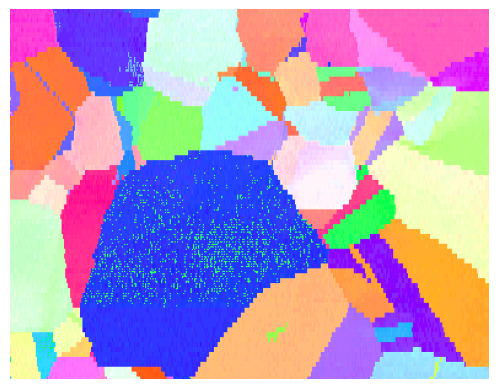

In [135]:
# show img 
plt.imshow(img)
plt.axis('off')
plt.show()

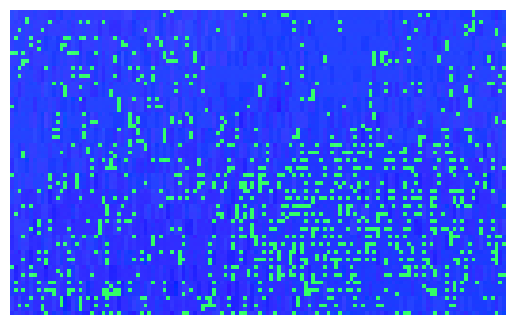

In [136]:
plt.imshow(img[140:220, 90:220])
plt.axis('off')

plt.show()

In [137]:
# run clustering algorithm on the img for blue vs green. only 2 clusters.
from sklearn.cluster import KMeans
def cluster_image(image, n_clusters=2):
    # Reshape the image to a 2D array of pixels
    pixels = image.reshape(-1, 3)
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(pixels)
    
    # Replace each pixel value with its cluster center
    clustered_pixels = kmeans.cluster_centers_[kmeans.labels_]
    
    # Reshape back to the original image shape
    clustered_image = clustered_pixels.reshape(image.shape).astype(np.uint8)
    
    return clustered_image


In [138]:
# Cluster the image
clustered_img = cluster_image(img[140:220, 90:220], n_clusters=2)
# how many pixels in each cluster
unique, counts = np.unique(clustered_img.reshape(-1, clustered_img.shape[2]), axis=0, return_counts=True)
print("Cluster counts:", dict(zip(map(tuple, unique), counts)))

Cluster counts: {(0, 0, 0): 1113, (0, 0, 1): 9287}


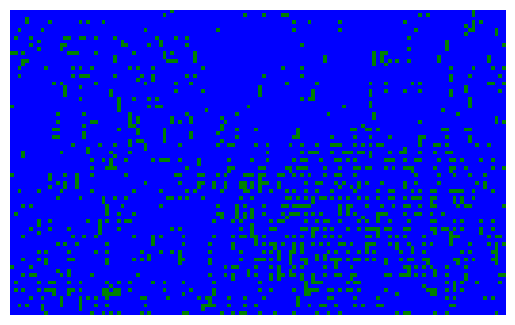

In [139]:
# Get cluster labels for each pixel
pixels = img[140:220, 90:220].reshape(-1, 3)
kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
labels = kmeans.labels_.reshape(img[140:220, 90:220].shape[:2])

# Display the clustered image using a colormap
cmap = mcolors.ListedColormap(['blue', 'green'])
plt.imshow(labels, cmap=cmap)
plt.axis('off')
plt.show()

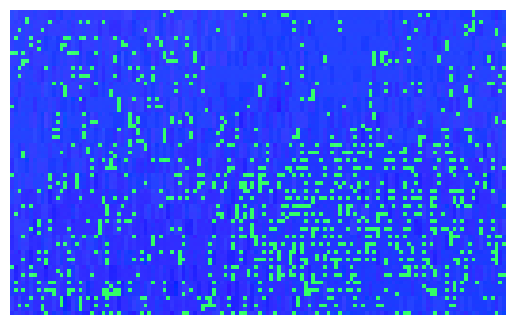

In [140]:
plt.imshow(img[140:220, 90:220])
plt.axis('off')

plt.show()

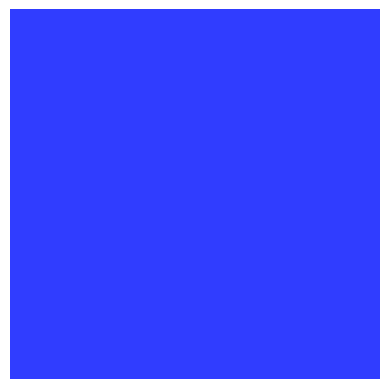

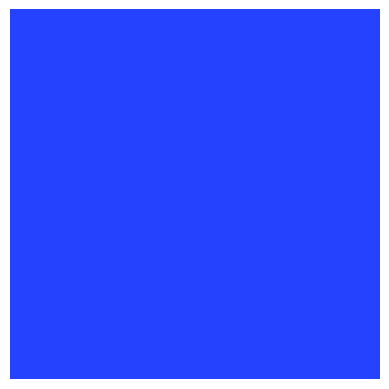

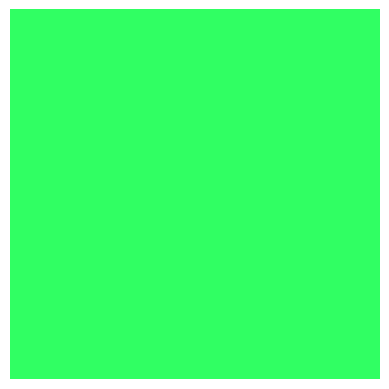

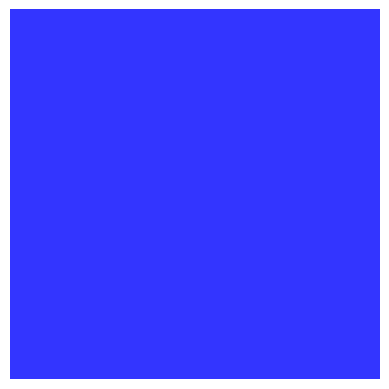

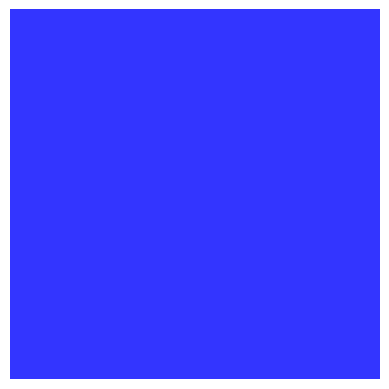

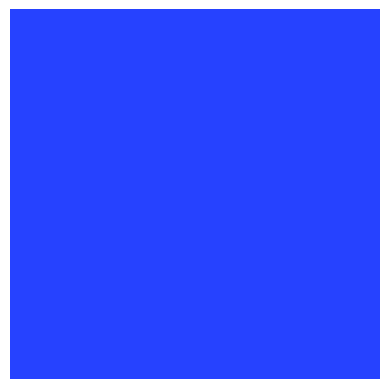

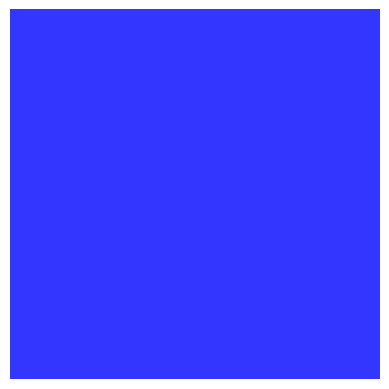

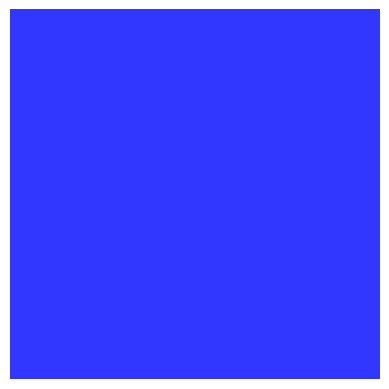

In [141]:
# pixels = [(162, 93), (162, 122), (163, 122), (164, 122), (160, 133), (160, 135), (161, 137)]
pixels = [(162, 93), (162, 122), (163, 122), (164, 122), (160, 133), (160, 135), (160, 137), (161, 137)]
for pixel in pixels:
    # show only original colors and only these pixels individually
    plt.imshow(img[pixel[0]:pixel[0]+1, pixel[1]:pixel[1]+1])
    plt.axis('off')
    plt.show()

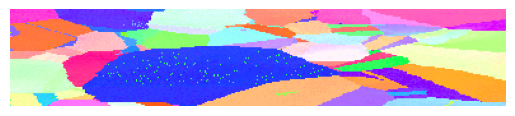

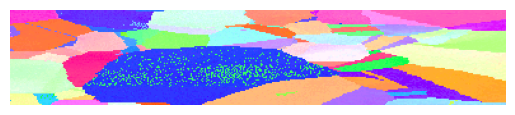

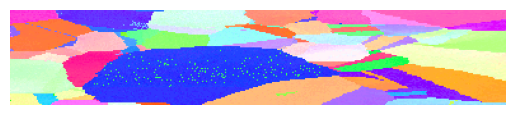

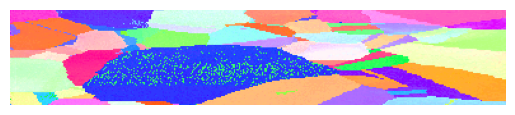

In [144]:
# mask every 4th row and do it 4 times starting from 0, 1, 2, 3
img_masked_0 = img[::4, :, :]
img_masked_1 = img[1::4, :, :]
img_masked_2 = img[2::4, :, :]
img_masked_3 = img[3::4, :, :]
# show img masked
plt.imshow(img_masked_0)
plt.axis('off')
plt.show()
plt.imshow(img_masked_1)
plt.axis('off')
plt.show()
plt.imshow(img_masked_2)
plt.axis('off')
plt.show()
plt.imshow(img_masked_3)
plt.axis('off')
plt.show()


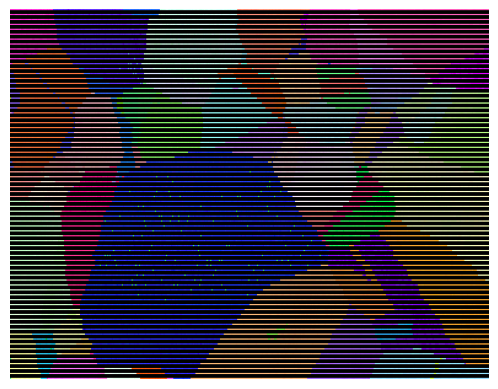

In [145]:
 # only keep every 4th row, black out the rest
img_masked = img.copy()
img_masked[1::4, :, :] = 0
img_masked[2::4, :, :] = 0
img_masked[3::4, :, :] = 0
# show img masked
plt.imshow(img_masked)
plt.axis('off')
plt.show()

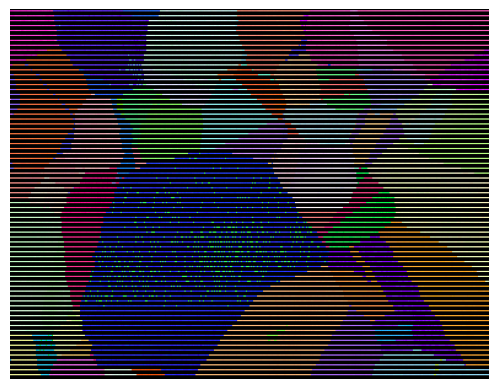

In [146]:
 # only keep every 4th row, black out the rest
img_masked = img.copy()
img_masked[0::4, :, :] = 0
img_masked[2::4, :, :] = 0
img_masked[3::4, :, :] = 0
# show img masked
plt.imshow(img_masked)
plt.axis('off')
plt.show()

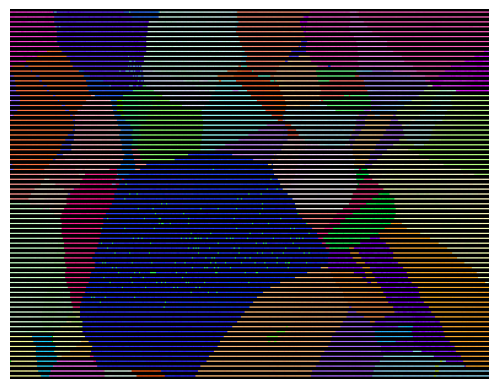

In [147]:
 # only keep every 4th row, black out the rest
img_masked = img.copy()
img_masked[0::4, :, :] = 0
img_masked[1::4, :, :] = 0
img_masked[3::4, :, :] = 0
# show img masked
plt.imshow(img_masked)
plt.axis('off')
plt.show()

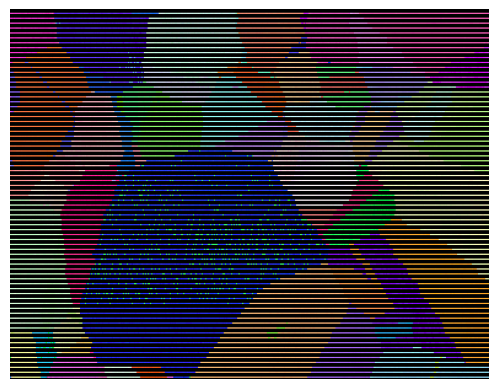

In [148]:
 # only keep every 4th row, black out the rest
img_masked = img.copy()
img_masked[0::4, :, :] = 0
img_masked[1::4, :, :] = 0
img_masked[2::4, :, :] = 0
# show img masked
plt.imshow(img_masked)
plt.axis('off')
plt.show()

## Load the quaternion data

In [149]:
import numpy as np

### Load fz reduced data

In [150]:
# load npy file 
npy_path= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_save_qrbsa_1d_model_best_minimum_angle_transformation.npy"
data = np.load(npy_path)

In [151]:
data.shape

(100, 304, 390, 4)

In [152]:
data_sampled = data[:, 90:220, 140:220, :]
print(data_sampled.shape)
data_sampled

(100, 130, 80, 4)


array([[[[ 0.07505853, -0.29964507, -0.13247341,  0.94182336],
         [ 0.0798585 , -0.29848766, -0.13293058,  0.94173163],
         [ 0.07483563, -0.29979464, -0.1325731 ,  0.9417794 ],
         ...,
         [ 0.20180324,  0.2763048 ,  0.20537868,  0.91692525],
         [-0.07787314, -0.02339156, -0.1080014 ,  0.99082065],
         [-0.07405919, -0.02446221, -0.09740658,  0.9921845 ]],

        [[ 0.0802905 , -0.29821515, -0.13222963,  0.94188   ],
         [ 0.08019769, -0.29892242, -0.13226163,  0.9416591 ],
         [ 0.07310325, -0.29188478, -0.13276398,  0.9443697 ],
         ...,
         [ 0.18740843, -0.22210921, -0.11893199,  0.9494219 ],
         [ 0.19062059, -0.22056036, -0.11939429,  0.9490854 ],
         [ 0.1874775 , -0.22563097, -0.11753693,  0.94875145]],

        [[ 0.07990818, -0.29836002, -0.13250057,  0.9418284 ],
         [ 0.07971876, -0.2983388 , -0.13233013,  0.94187516],
         [ 0.07260161, -0.29175022, -0.13271245,  0.94445723],
         ...,
         

In [153]:
# Sort the last dimension (axis=-1) in-place for each sample at position [0,0]
temp =data_sampled[:, 2, 20, -1]
# sort temp
temp_sorted = np.sort(temp)
temp_sorted


array([0.9144944 , 0.91455156, 0.914554  , 0.9145615 , 0.91456974,
       0.9145722 , 0.91457593, 0.91458166, 0.91458577, 0.91459423,
       0.91459596, 0.914611  , 0.9146115 , 0.91462535, 0.9146371 ,
       0.91463745, 0.9146386 , 0.91463983, 0.9146428 , 0.9146484 ,
       0.914651  , 0.91465324, 0.9146599 , 0.91466236, 0.9146645 ,
       0.9146645 , 0.9146665 , 0.91466683, 0.9146672 , 0.91466826,
       0.9146683 , 0.9146688 , 0.91467404, 0.91467583, 0.9146806 ,
       0.9146812 , 0.914683  , 0.91468334, 0.9146872 , 0.9146873 ,
       0.9146879 , 0.9146884 , 0.9146887 , 0.9146889 , 0.91468906,
       0.9146961 , 0.9146961 , 0.91469735, 0.9146975 , 0.9146988 ,
       0.91469985, 0.91470224, 0.91470474, 0.9147054 , 0.91470814,
       0.9147095 , 0.91470957, 0.91470987, 0.9147107 , 0.9147113 ,
       0.9147134 , 0.9147135 , 0.9147146 , 0.9147147 , 0.9147183 ,
       0.9147191 , 0.9147193 , 0.9147241 , 0.9147279 , 0.9147284 ,
       0.91473293, 0.91473377, 0.9147346 , 0.9147353 , 0.91473

In [154]:
temp.shape

(100,)

In [155]:
# clustered img pixels
labels[:,0]
labels.shape

(80, 130)

In [156]:
labels = labels.T
# expand labels [130, 80] to match data_sampled [100, 130, 80, 4]
labels_expanded = np.zeros((data_sampled.shape[0], data_sampled.shape[1], data_sampled.shape[2], 4))
for i in range(4):
    labels_expanded[:, :, :, i] = labels

In [157]:
labels.shape

(130, 80)

In [158]:
# find total count of how many 1 in labels
total_count = np.sum(labels == 1)
total_count
ratio_labels = np.sum(labels==1) / labels.size
print("Ratio of labels 1 to 0:", ratio_labels)

Ratio of labels 1 to 0: 0.10701923076923077


In [159]:
labels_expanded.shape

(100, 130, 80, 4)

## 

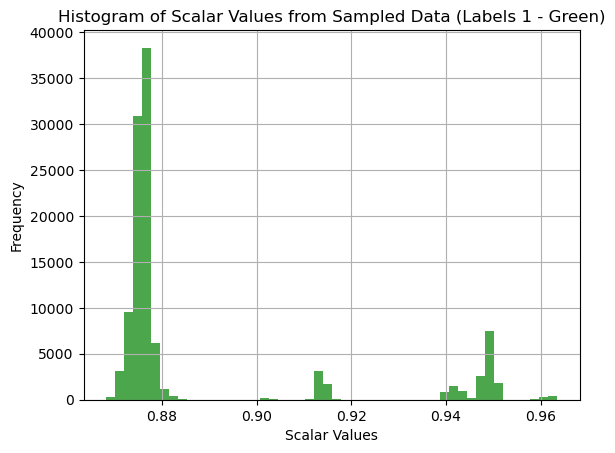

In [160]:
# select pixels from data_sampled where labels_expanded is 1, retain the data sampled shape

sampled_data= data_sampled[labels_expanded == 1]
sampled_data=sampled_data.reshape(100, -1, 4) 

#Now extract the scalar of the quaternion from the sampled data
sampled_data_scalar_green = sampled_data[..., -1]  # Assuming the scalar part is the first element in the last dimension

# plot histogram of the scalar values, average value, and standard deviation
mean_median_scalar_green = np.mean(np.median(sampled_data_scalar_green, axis=0))
std_scalar_green = np.std(sampled_data_scalar_green)
plt.hist(sampled_data_scalar_green.flatten(), bins=50, color='green', alpha=0.7)
plt.xlabel('Scalar Values')
plt.ylabel('Frequency')
plt.title('Histogram of Scalar Values from Sampled Data (Labels 1 - Green)')
plt.grid(True)
plt.show()

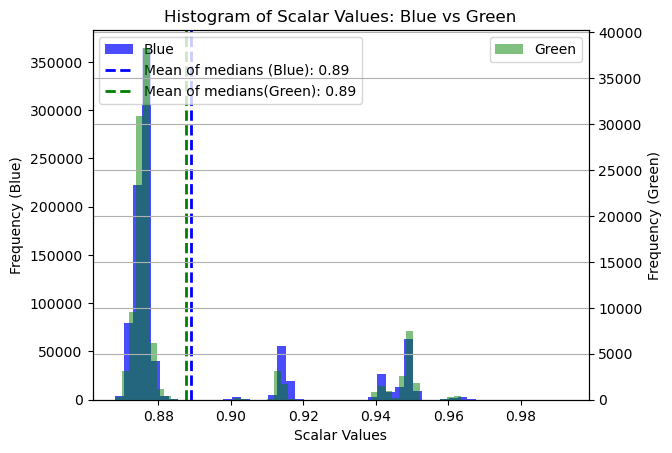

In [161]:
# select pixels from data_sampled where labels_expanded is 1, retain the data sampled shape

sampled_data= data_sampled[labels_expanded == 0]
sampled_data=sampled_data.reshape(100, -1, 4) 

#Now extract the scalar of the quaternion from the sampled data
sampled_data_scalar_blue = sampled_data[..., -1]  # Assuming the scalar part is the first element in the last dimension
# plot histogram of the scalar values, mean of the median values, and standard deviation
mean_median_scalar_blue = np.mean(np.median(sampled_data_scalar_blue, axis=0))
std_scalar_blue = np.std(sampled_data_scalar_blue)
plt.hist(sampled_data_scalar_blue.flatten(), bins=50, color='blue', alpha=0.7, label='Blue')
plt.axvline(mean_median_scalar_blue, color='blue', linestyle='dashed', linewidth=2, label=f'Mean of medians (Blue): {mean_median_scalar_blue:.2f}')
plt.axvline(mean_median_scalar_green, color='green', linestyle='dashed', linewidth=2, label=f'Mean of medians(Green): {mean_median_scalar_green:.2f}')
# Plot the green scalar values histogram on a separate y-axis
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.hist(sampled_data_scalar_green.flatten(), bins=50, color='green', alpha=0.5, label='Green')
ax2.set_ylabel('Frequency (Green)')

ax1.set_xlabel('Scalar Values')
ax1.set_ylabel('Frequency (Blue)')
plt.title('Histogram of Scalar Values: Blue vs Green')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.show()


In [162]:
import torch
2*torch.arccos(torch.tensor(0.86)).item() * 180 / np.pi

61.36683180559838

In [163]:
print("Mean of median scalar values (Green):", mean_median_scalar_green)
print("Standard deviation of scalar values (Green):", std_scalar_green)
print("Mean of median scalar values (Blue):", mean_median_scalar_blue)
print("Standard deviation of scalar values (Blue):", std_scalar_blue)

Mean of median scalar values (Green): 0.8877812
Standard deviation of scalar values (Green): 0.026148895
Mean of median scalar values (Blue): 0.8889526
Standard deviation of scalar values (Blue): 0.026018335


In [164]:
import torch
angle = torch.arccos(torch.tensor(mean_median_scalar_green))
angle_degrees = angle.item() * (180 / np.pi)  # Convert radians to degrees
print(f"Angle in degrees: {angle_degrees:.2f}°")

Angle in degrees: 27.40°


In [165]:
import torch
angle = torch.arccos(torch.tensor(0.87))
angle_degrees = angle.item() * (180 / np.pi)  # Convert radians to degrees
print(f"Angle in degrees: {angle_degrees:.2f}°")

Angle in degrees: 29.54°


In [166]:
# get the median distribution of the scalar values for each pixel
median_scalar_green = np.median(sampled_data_scalar_green, axis=0)
# threshold the median scalar values to get the pixels that are above a certain threshold
threshold = 0.89  # Set your threshold value
above_threshold_pixels = np.where(median_scalar_green > threshold)[0]
ratio_above_threshold = len(above_threshold_pixels) / median_scalar_green.size
print(f"Number of green pixels above threshold {threshold}: {len(above_threshold_pixels)}")
print(f"Ratio of green pixels above threshold {threshold}: {ratio_above_threshold:.2f}")
above_threshold_pixels

Number of green pixels above threshold 0.89: 214
Ratio of green pixels above threshold 0.89: 0.19


array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [167]:
# get the median distribution of the scalar values for each pixel
median_scalar_blue = np.median(sampled_data_scalar_blue, axis=0)
# threshold the median scalar values to get the pixels that are above a certain threshold
threshold = 0.89  # Set your threshold value
above_threshold_pixels = np.where(median_scalar_blue > threshold)[0]
ratio_above_threshold = len(above_threshold_pixels) / median_scalar_blue.size
print(f"Number of blue pixels above threshold {threshold}: {len(above_threshold_pixels)}")
print(f"Ratio of blue pixels above threshold {threshold}: {ratio_above_threshold:.2f}")
above_threshold_pixels

Number of blue pixels above threshold 0.89: 2134
Ratio of blue pixels above threshold 0.89: 0.23


array([   0,    1,    2, ..., 3491, 3565, 3566])

In [168]:
median_scalar_green[median_scalar_green <0.89]

array([0.87608445, 0.8760494 , 0.87608075, 0.8761182 , 0.8723031 ,
       0.8760816 , 0.8708352 , 0.87511736, 0.8746668 , 0.87610364,
       0.8761171 , 0.87611634, 0.87611455, 0.8761085 , 0.8761221 ,
       0.8760556 , 0.87074274, 0.8762051 , 0.87655437, 0.8760823 ,
       0.8760552 , 0.876053  , 0.87609416, 0.87605274, 0.87598073,
       0.87253773, 0.87756765, 0.8774717 , 0.8760021 , 0.8745646 ,
       0.8760229 , 0.8760582 , 0.8761735 , 0.87072957, 0.8761756 ,
       0.87614304, 0.8761322 , 0.87152547, 0.8764063 , 0.8693173 ,
       0.87614626, 0.87779236, 0.8759973 , 0.8761705 , 0.87615764,
       0.8762548 , 0.8766248 , 0.8760216 , 0.8760589 , 0.8760681 ,
       0.87604797, 0.87742424, 0.8706846 , 0.8746245 , 0.8745867 ,
       0.8692095 , 0.8775119 , 0.8760519 , 0.8747193 , 0.876129  ,
       0.87614846, 0.8709576 , 0.87603647, 0.87589896, 0.876248  ,
       0.8764347 , 0.87631214, 0.87275964, 0.8821183 , 0.8735284 ,
       0.87608886, 0.8707113 , 0.87053597, 0.873566  , 0.87084

In [169]:
median_scalar_green

array([0.9431788 , 0.91555953, 0.91561234, ..., 0.8760902 , 0.877426  ,
       0.87576264], dtype=float32)

In [170]:
median_scalar_blue[median_scalar_blue <0.89]

array([0.87633723, 0.8762909 , 0.8711103 , ..., 0.8747443 , 0.8765576 ,
       0.8748307 ], dtype=float32)

In [171]:
sampled_data_scalar_green.shape

(100, 1113)

In [172]:
sampled_data_scalar_green= sampled_data_scalar_green.T
sampled_data_scalar_blue= sampled_data_scalar_blue.T

In [173]:
# sort 0th dimension for every pixel in 1st dimension in the median scalar_green in ascending order. 
sorted_scalar_green = np.sort(sampled_data_scalar_green, axis=1)
print(sorted_scalar_green.shape)

(1113, 100)


In [174]:
#  PIXEL first, values second
sorted_scalar_green

array([[0.9429992 , 0.94301414, 0.9430302 , ..., 0.9434219 , 0.9435192 ,
        0.94356954],
       [0.9151474 , 0.91518426, 0.9153136 , ..., 0.9157824 , 0.9157846 ,
        0.9158079 ],
       [0.9152676 , 0.9152868 , 0.91529703, ..., 0.9157926 , 0.91581106,
        0.9158343 ],
       ...,
       [0.8744012 , 0.8744067 , 0.8744744 , ..., 0.877891  , 0.87792355,
        0.8779573 ],
       [0.87506217, 0.8751574 , 0.8754089 , ..., 0.87924725, 0.87927526,
        0.8792939 ],
       [0.8734951 , 0.8739417 , 0.8740173 , ..., 0.87935126, 0.8794018 ,
        0.87947387]], dtype=float32)

In [175]:
# check for first pixel
sorted_scalar_green[0,:]

array([0.9429992 , 0.94301414, 0.9430302 , 0.94303566, 0.9430448 ,
       0.94304514, 0.94305235, 0.9430592 , 0.94305927, 0.94306016,
       0.94306374, 0.94307595, 0.9430826 , 0.9430845 , 0.9430852 ,
       0.9430878 , 0.9430905 , 0.94309515, 0.94309866, 0.9430995 ,
       0.9431041 , 0.9431054 , 0.94311017, 0.9431121 , 0.9431152 ,
       0.94311637, 0.94311863, 0.94312143, 0.9431236 , 0.9431251 ,
       0.94312567, 0.9431266 , 0.94312996, 0.9431301 , 0.94314253,
       0.943143  , 0.94314414, 0.9431453 , 0.9431475 , 0.9431499 ,
       0.9431518 , 0.9431536 , 0.94315386, 0.9431603 , 0.9431609 ,
       0.9431654 , 0.94316715, 0.94316816, 0.94317067, 0.9431777 ,
       0.94317985, 0.9431844 , 0.94318634, 0.94318974, 0.94320136,
       0.9432125 , 0.9432135 , 0.943214  , 0.94321775, 0.94321954,
       0.943228  , 0.9432318 , 0.9432421 , 0.94324267, 0.94324934,
       0.94325185, 0.94325197, 0.9432658 , 0.9432694 , 0.9432741 ,
       0.94327825, 0.94328314, 0.943289  , 0.943292  , 0.94329

In [176]:
# CHECK FOr the last pixel
sorted_scalar_green[-1,:]

array([0.8734951 , 0.8739417 , 0.8740173 , 0.87406844, 0.87485665,
       0.87486494, 0.8748917 , 0.87494415, 0.87500525, 0.8750099 ,
       0.875015  , 0.8750164 , 0.87510204, 0.8751203 , 0.8751248 ,
       0.8751447 , 0.87519175, 0.87522304, 0.87524045, 0.87526536,
       0.8752829 , 0.87530345, 0.8753037 , 0.8753092 , 0.87533283,
       0.875366  , 0.87543714, 0.87545633, 0.87550056, 0.8755423 ,
       0.8755426 , 0.8755462 , 0.87554634, 0.8755513 , 0.87556696,
       0.8755852 , 0.87558866, 0.87559265, 0.87560356, 0.87560546,
       0.8756109 , 0.8756426 , 0.87564677, 0.8756582 , 0.87567365,
       0.8756926 , 0.87572765, 0.87573177, 0.875747  , 0.8757622 ,
       0.87576306, 0.87578464, 0.8757847 , 0.8757911 , 0.8758078 ,
       0.8758132 , 0.87581635, 0.87582713, 0.8759593 , 0.8764705 ,
       0.8769144 , 0.87697196, 0.87700075, 0.8770044 , 0.8770722 ,
       0.87710094, 0.87712806, 0.8771494 , 0.8776839 , 0.87774503,
       0.877872  , 0.8780647 , 0.878136  , 0.87817055, 0.87820

In [177]:
sorted_scalar_blue = np.sort(sampled_data_scalar_blue, axis=1)
#  PIXEL first, values second
print(sorted_scalar_blue.shape)
# check for first pixel
sorted_scalar_blue[0,:]

(9287, 100)


array([0.94150454, 0.9415123 , 0.94153476, 0.9415438 , 0.9415442 ,
       0.9415482 , 0.9415719 , 0.9415728 , 0.9415741 , 0.9415744 ,
       0.9415829 , 0.94159317, 0.94159347, 0.94159365, 0.941595  ,
       0.9416017 , 0.9416058 , 0.94161725, 0.94161797, 0.9416222 ,
       0.9416306 , 0.94163334, 0.9416433 , 0.9416468 , 0.9416554 ,
       0.9416635 , 0.9416683 , 0.94168854, 0.94169587, 0.94169694,
       0.94170284, 0.94170773, 0.94171345, 0.9417171 , 0.9417173 ,
       0.9417227 , 0.9417247 , 0.941731  , 0.94173247, 0.94174   ,
       0.94175184, 0.94175315, 0.9417553 , 0.9417581 , 0.9417634 ,
       0.9417641 , 0.94176567, 0.9417661 , 0.9417663 , 0.9417691 ,
       0.94177115, 0.94177175, 0.94177747, 0.9417777 , 0.9417784 ,
       0.9417794 , 0.94178015, 0.94178104, 0.94178367, 0.9417843 ,
       0.94178665, 0.941788  , 0.9417887 , 0.9417961 , 0.94180095,
       0.94180346, 0.9418036 , 0.94180554, 0.94180846, 0.9418086 ,
       0.9418106 , 0.94181174, 0.94181204, 0.9418151 , 0.94181

In [178]:
# # compare with the sorted first pixel data to confirm right operations 
# data --->
# array([0.94150454, 0.9415321 , 0.94153476, 0.9415438 , 0.9415482 ,
#        0.9415719 , 0.9415728 , 0.9415741 , 0.94157445, 0.9415829 ,
#        0.94159317, 0.94159347, 0.94159365, 0.941595  , 0.9416017 ,
#        0.9416058 , 0.94161725, 0.9416207 , 0.9416222 , 0.9416306 ,
#        0.94163334, 0.9416432 , 0.9416468 , 0.9416554 , 0.9416635 ,
#        0.94166803, 0.9416683 , 0.94168854, 0.9416959 , 0.94169694,
#        0.94170284, 0.94170773, 0.94171345, 0.9417171 , 0.9417227 ,
#        0.9417247 , 0.941731  , 0.94173247, 0.94174   , 0.94175184,
#        0.94175273, 0.94175327, 0.9417553 , 0.9417581 , 0.94176304,
#        0.9417634 , 0.9417643 , 0.94176567, 0.9417661 , 0.9417663 ,
#        0.9417691 , 0.94177115, 0.94177175, 0.94177747, 0.9417777 ,
#        0.9417784 , 0.94178015, 0.94178104, 0.94178367, 0.9417843 ,
#        0.94178665, 0.941788  , 0.9417887 , 0.9417961 , 0.9418008 ,
#        0.94180346, 0.9418036 , 0.94180554, 0.9418086 , 0.9418106 ,
#        0.9418119 , 0.94181514, 0.94181764, 0.94182336, 0.94182336,
#        0.9418238 , 0.94182503, 0.9418254 , 0.9418254 , 0.94182783,
#        0.94183296, 0.94183546, 0.94183606, 0.94183886, 0.9418413 ,
#        0.9418467 , 0.9418529 , 0.9418544 , 0.9418577 , 0.94186527,
#        0.9418665 , 0.94187516, 0.94188297, 0.94191605, 0.9419274 ,
#        0.94192785, 0.9419297 , 0.94195074, 0.9419589 , 0.9419959 ],
#       dtype=float32)

In [179]:
# get the median distribution of the scalar values for each pixel
median_scalar_blue = np.median(sampled_data_scalar_blue, axis=1)
# threshold the median scalar values to get the pixels that are above a certain threshold
threshold = 0.88  # Set your threshold value
below_threshold_pixels = np.where(median_scalar_blue < threshold)[0]
ratio_below_threshold = len(below_threshold_pixels) / median_scalar_blue.size
print(f"Number of pixels below threshold {threshold}: {len(below_threshold_pixels)}")
print(f"Ratio of pixels below threshold {threshold}: {ratio_below_threshold:.2f}")
below_threshold_pixels

Number of pixels below threshold 0.88: 7149
Ratio of pixels below threshold 0.88: 0.77


array([1831, 1832, 1833, ..., 9284, 9285, 9286])

In [180]:
# get the median distribution of the scalar values for each pixel
median_scalar_green = np.median(sampled_data_scalar_green, axis=1)
# threshold the median scalar values to get the pixels that are above a certain threshold
threshold = 0.87  # Set your threshold value
below_threshold_pixels = np.where(median_scalar_green < threshold)[0]
ratio_below_threshold = len(below_threshold_pixels) / median_scalar_green.size
print(f"Number of pixels below threshold {threshold}: {len(below_threshold_pixels)}")
print(f"Ratio of pixels below threshold {threshold}: {ratio_below_threshold:.2f}")
below_threshold_pixels

Number of pixels below threshold 0.87: 2
Ratio of pixels below threshold 0.87: 0.00


array([244, 262])

In [181]:
# find x,y indices where labels is 1
x_indices, y_indices = np.where(labels == 1)

In [182]:
x_indices, y_indices
# pick 10 random indices from the x_indices and y_indices
import random
random_indices = random.sample(range(len(x_indices)), 10)
# get the x,y coordinates of the random indices
random_x = x_indices[random_indices]
random_y = y_indices[random_indices]
# print the random x,y coordinates
for i in range(len(random_x)):
    print(f"Random pixel {i}: ({random_x[i]}, {random_y[i]})")

Random pixel 0: (26, 21)
Random pixel 1: (20, 75)
Random pixel 2: (59, 33)
Random pixel 3: (66, 59)
Random pixel 4: (12, 31)
Random pixel 5: (25, 77)
Random pixel 6: (74, 73)
Random pixel 7: (62, 43)
Random pixel 8: (119, 20)
Random pixel 9: (43, 19)


In [183]:
# Use first 10 x,y coordinates instead of random sampling
random_x = x_indices[:10]
random_y = y_indices[:10]
# print the first 10 x,y coordinates
for i in range(len(random_x)):
    print(f"First pixel {i}: ({random_x[i]}, {random_y[i]})")


First pixel 0: (0, 11)
First pixel 1: (0, 25)
First pixel 2: (0, 43)
First pixel 3: (0, 67)
First pixel 4: (1, 7)
First pixel 5: (1, 11)
First pixel 6: (1, 53)
First pixel 7: (1, 71)
First pixel 8: (1, 73)
First pixel 9: (2, 5)


In [184]:
blue_grain= img[140:220, 90:220]

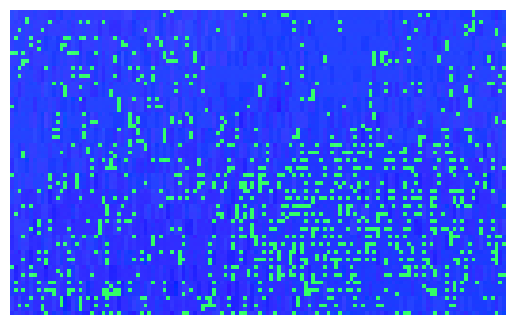

In [185]:
# plot the blue grain image
plt.imshow(blue_grain)
plt.axis('off')
plt.show()

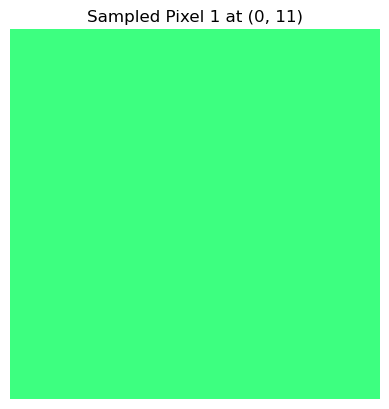

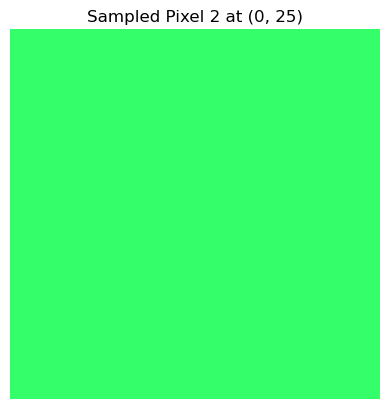

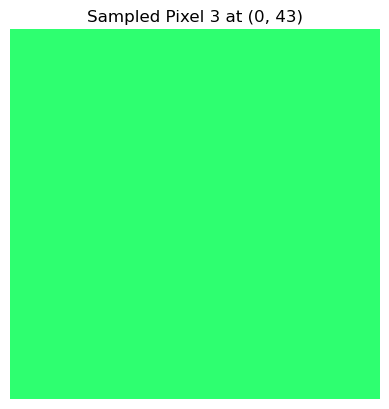

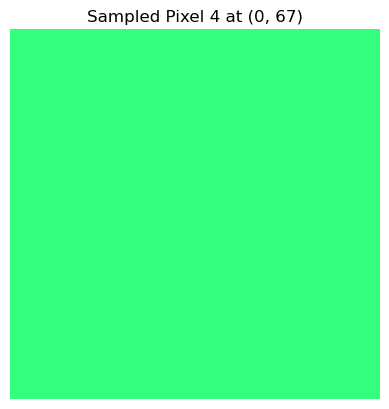

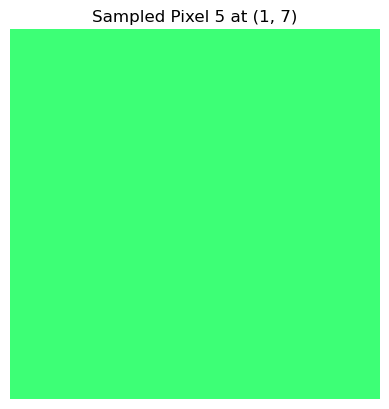

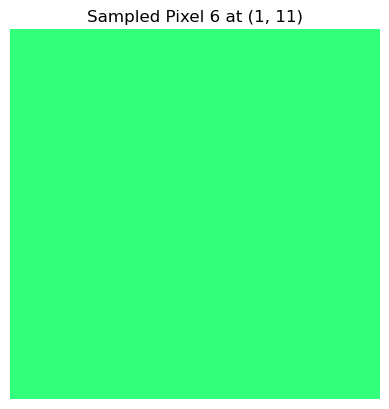

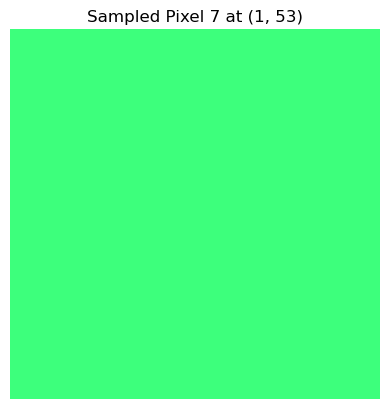

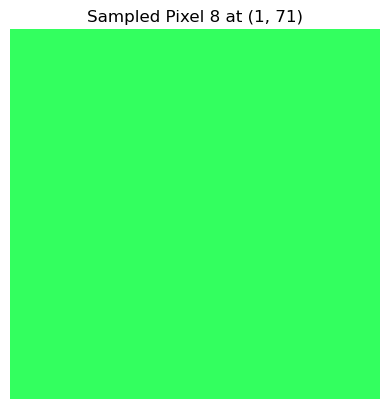

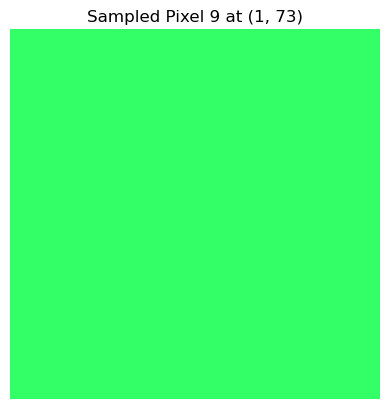

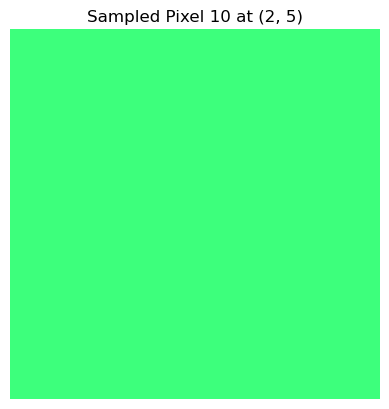

In [186]:
# sample the pixels from the blue grain image at the random x,y coordinates
sampled_pixels = blue_grain[random_y, random_x]
sampled_pixels.shape
# plot the sampled pixels individually
for i in range(len(sampled_pixels)):
    plt.imshow(sampled_pixels[i].reshape(1, -1, 3))  # Reshape to 1x1 pixel
    plt.axis('off')
    plt.title(f"Sampled Pixel {i+1} at ({random_x[i]}, {random_y[i]})")
    plt.show()

In [187]:
# get the relevant quaternions
quaternions = data[:, 140+random_y, 90+random_x, :]

In [188]:
quat_scalar= quaternions[..., -1]  # Assuming the scalar part is the last element in the last dimension
# get the median of the scalar values for each pixel
median_quat_scalar = np.median(quat_scalar, axis=0)
median_quat_scalar

array([0.87211144, 0.8724717 , 0.87288535, 0.8746649 , 0.87519944,
       0.8717871 , 0.8724222 , 0.8732632 , 0.87310547, 0.8725331 ],
      dtype=float32)

In [189]:
quat_scalar.shape, median_quat_scalar.shape

((100, 10), (10,))

### Quaternion Pixels that lead to green

In [190]:
# For each pixel, find the time index where the scalar value is closest to the median
median_quat_indices = np.argmin(np.abs(quat_scalar - median_quat_scalar), axis=0)

# Extract the quaternions corresponding to these indices for each pixel
median_quat = quaternions[median_quat_indices, np.arange(10), :]
print("Median Quaternions for green Sampled Pixels:")
for i in range(len(median_quat)):
    print(f"Pixel {i+1} at ({random_x[i]}, {random_y[i]}): {median_quat[i]}")


Median Quaternions for green Sampled Pixels:
Pixel 1 at (0, 11): [-0.35607085  0.28366578 -0.1793553   0.8721117 ]
Pixel 2 at (0, 25): [-0.35784054  0.28689945 -0.16860943  0.8724741 ]
Pixel 3 at (0, 43): [-0.35953808  0.28698856 -0.16261834  0.87288326]
Pixel 4 at (0, 67): [0.35526362 0.3204002  0.07815591 0.8746565 ]
Pixel 5 at (1, 7): [-0.35816842  0.27979103 -0.16569881  0.8752008 ]
Pixel 6 at (1, 11): [-0.35782075  0.1768896   0.2840124   0.87178576]
Pixel 7 at (1, 53): [-0.35856968  0.28628933 -0.16837195  0.8724205 ]
Pixel 8 at (1, 71): [0.36009863 0.31783667 0.08203066 0.8732586 ]
Pixel 9 at (1, 73): [0.3573338  0.32111257 0.08292328 0.8731107 ]
Pixel 10 at (2, 5): [-0.35894728  0.2861494  -0.16728848  0.8725192 ]


In [191]:
quaternions[:,0,-1]

array([0.87067723, 0.8710569 , 0.87294996, 0.8721379 , 0.87100965,
       0.870981  , 0.8742437 , 0.87307215, 0.8723256 , 0.8727668 ,
       0.87076056, 0.8704893 , 0.8710412 , 0.8714661 , 0.87288374,
       0.871907  , 0.87285864, 0.87267846, 0.8728039 , 0.8697255 ,
       0.872677  , 0.8711059 , 0.86969745, 0.8720539 , 0.8727246 ,
       0.872282  , 0.87298524, 0.8729147 , 0.87299836, 0.872175  ,
       0.8707104 , 0.87229145, 0.87296   , 0.87208664, 0.870617  ,
       0.8721    , 0.8721117 , 0.87219906, 0.8712553 , 0.87293077,
       0.870554  , 0.8722002 , 0.87211114, 0.8710208 , 0.8729675 ,
       0.8727356 , 0.87372506, 0.87179726, 0.8712578 , 0.87293047,
       0.87163806, 0.8740995 , 0.8721897 , 0.874331  , 0.87298375,
       0.87218547, 0.8719814 , 0.8695145 , 0.8706285 , 0.8742857 ,
       0.87102467, 0.87386936, 0.87369925, 0.8705075 , 0.87180364,
       0.87081224, 0.8734938 , 0.8719059 , 0.87289375, 0.8728783 ,
       0.87201285, 0.8728406 , 0.8717413 , 0.87228143, 0.87138

In [192]:
# sort np array quaternions[:,0,-1]
sorted_quaternions = np.sort(quaternions[:, 0, -1])
# Print the sorted quaternions
print("Sorted quaternions shape:", sorted_quaternions.shape)
print(sorted_quaternions)

Sorted quaternions shape: (100,)
[0.86951256 0.8695145  0.86969745 0.86972475 0.8697255  0.8704893
 0.8705075  0.87051827 0.8705188  0.8705272  0.8705382  0.87053937
 0.870554   0.870617   0.8706285  0.87067723 0.8707104  0.87076056
 0.8707614  0.87081224 0.8708503  0.8708584  0.870981   0.87100965
 0.8710208  0.87102467 0.8710412  0.8710569  0.87109375 0.8711059
 0.8712553  0.8712578  0.871333   0.871333   0.8713825  0.8714661
 0.87163806 0.8717413  0.87179726 0.87180364 0.8719059  0.871907
 0.8719488  0.8719814  0.87201285 0.8720489  0.8720539  0.87208664
 0.8721     0.87211114 0.8721117  0.8721379  0.8721534  0.872175
 0.87218547 0.8721897  0.87219906 0.8722002  0.8722471  0.87228143
 0.872282   0.87229145 0.8723256  0.8723742  0.872677   0.87267846
 0.8727246  0.8727356  0.8727356  0.8727668  0.8727857  0.8728039
 0.8728406  0.87285864 0.8728783  0.87288374 0.87289375 0.8729147
 0.87293047 0.87293077 0.87294996 0.87296    0.8729675  0.87298375
 0.87298524 0.87299836 0.8730331  0.87

### Load the fz_reduced data

In [193]:
fz_reduced_npy_dir = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_save_qrbsa_1d_model_best_minimum_angle_transformation.npy"
fz_reduced_data = np.load(fz_reduced_npy_dir)
fz_reduced_data.shape

(100, 304, 390, 4)

### Load the not fz reduced data

In [194]:
not_fz_reduced_npy_dir = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_not_fz_reduced_qrbsa_1d_model_best_minimum_angle_transformation.npy"
not_fz_reduced_data = np.load(not_fz_reduced_npy_dir)
not_fz_reduced_data.shape

(100, 304, 390, 4)

In [195]:
not_fz_reduced_data_sampled = not_fz_reduced_data[:, 90:220, 140:220, :]
fz_reduced_data_sampled = fz_reduced_data[:, 90:220, 140:220, :]

In [196]:
#fz_reduced_data_sampled

### Display the green quaternions 

Random pixel 0: (103, 21)
Random pixel 1: (81, 77)
Random pixel 2: (1, 11)
Random pixel 3: (31, 71)
Random pixel 4: (82, 55)
Random pixel 5: (121, 65)
Random pixel 6: (86, 73)
Random pixel 7: (28, 31)
Random pixel 8: (16, 73)
Random pixel 9: (53, 71)
First pixel 0: (0, 11)
First pixel 1: (0, 25)
First pixel 2: (0, 43)
First pixel 3: (0, 67)
First pixel 4: (1, 7)
First pixel 5: (1, 11)
First pixel 6: (1, 53)
First pixel 7: (1, 71)
First pixel 8: (1, 73)
First pixel 9: (2, 5)


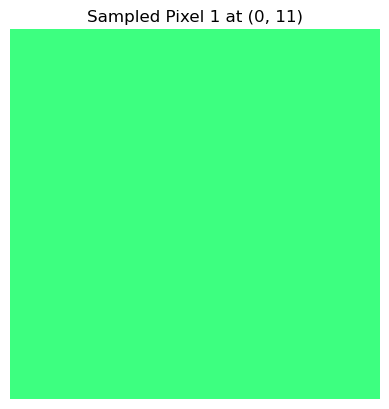

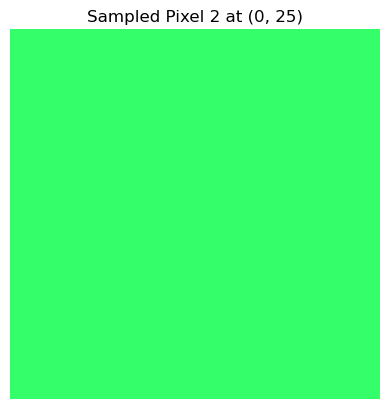

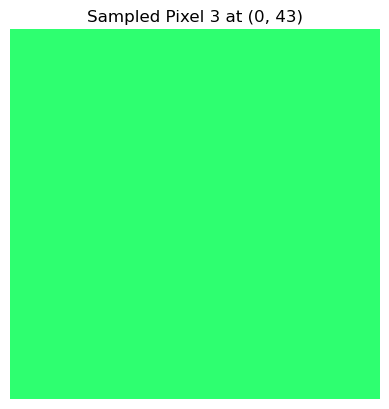

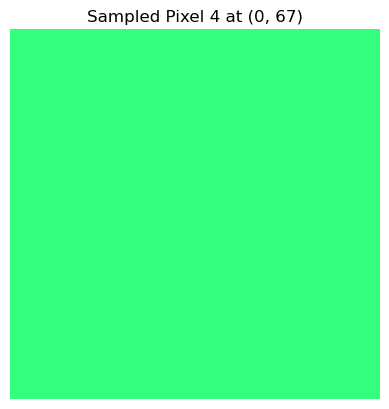

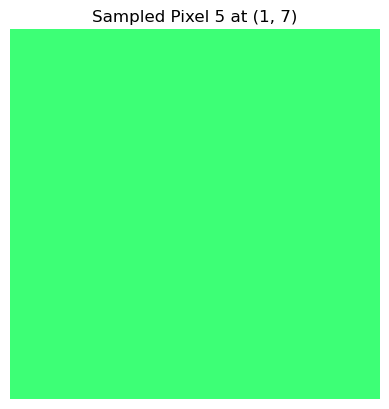

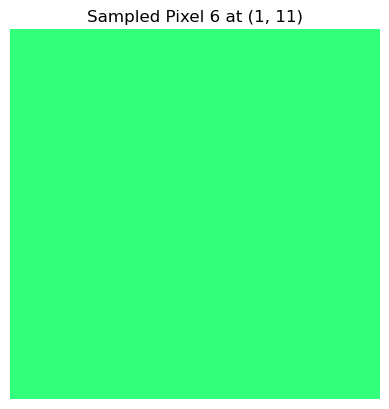

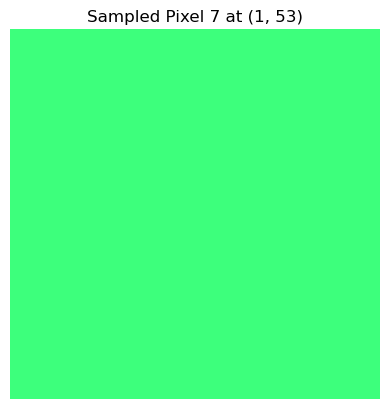

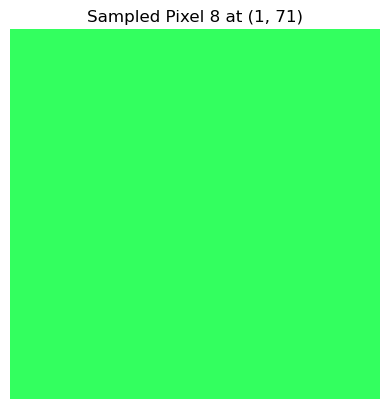

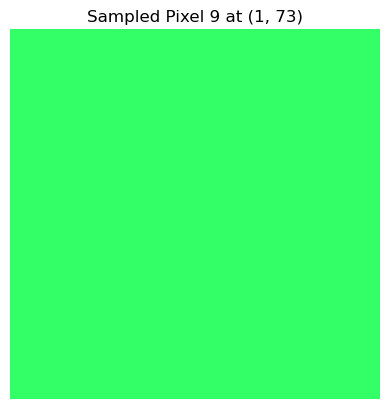

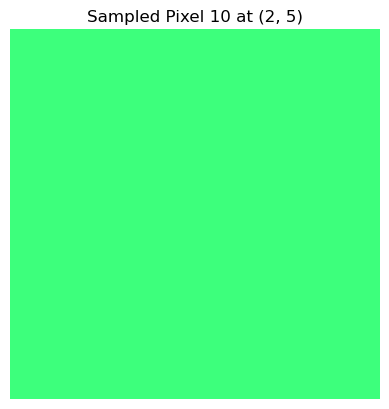

Median quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for green Pixel 1 at (0, 11): [ 0.26754582 -0.15486704 -0.75967145  0.5721316 ]
Median Quaternion for green Pixel 2 at (0, 25): [ 0.72346    -0.31057626  0.11103532  0.60648143]
Median Quaternion for green Pixel 3 at (0, 43): [ 0.87584054 -0.16261624 -0.2828368   0.35561562]
Median Quaternion for green Pixel 4 at (0, 67): [ 0.8783544  -0.14681625 -0.28313166  0.3560554 ]
Median Quaternion for green Pixel 5 at (1, 7): [ 0.26707643 -0.15652129 -0.7643729   0.56560206]
Median Quaternion for green Pixel 6 at (1, 11): [ 0.26755545 -0.15491316 -0.75979406  0.5719518 ]
Median Quaternion for green Pixel 7 at (1, 53): [ 0.4959523  -0.73542464  0.04689714  0.45932737]
Median Quaternion for green Pixel 8 at (1, 71): [ 0.82095224 -0.41267872  0.13785821  0.36976814]
Median Quaternion for green Pixel 9 at (1, 73): [0.81964606 0.14197719 0.41708672 0.36614355]
Median Quaternion for green Pixel 10 at (2, 5): [ 0.7225367  -0.30460903

In [197]:
# get the relevant quaternions
# Contrast the median quaternion values between fz_reduce and not_fz_reduce for the green pixels
# find x,y indices where labels is 1
x_indices, y_indices = np.where(labels == 1)
# pick 10 random indices from the x_indices and y_indices
import random
random_indices = random.sample(range(len(x_indices)), 10)
# get the x,y coordinates of the random indices
random_x = x_indices[random_indices]
random_y = y_indices[random_indices]
# print the random x,y coordinates
for i in range(len(random_x)):
    print(f"Random pixel {i}: ({random_x[i]}, {random_y[i]})")
# Use first 10 x,y coordinates instead of random sampling
random_x = x_indices[:10]
random_y = y_indices[:10]
# print the first 10 x,y coordinates
for i in range(len(random_x)):
    print(f"First pixel {i}: ({random_x[i]}, {random_y[i]})")
# sample the pixels from the blue grain image at the random x,y coordinates
sampled_pixels = blue_grain[random_y, random_x]
sampled_pixels.shape
# plot the sampled pixels individually
for i in range(len(sampled_pixels)):
    plt.imshow(sampled_pixels[i].reshape(1, -1, 3))  # Reshape to 1x1 pixel
    plt.axis('off')
    plt.title(f"Sampled Pixel {i+1} at ({random_x[i]}, {random_y[i]})")
    plt.show()

# get the relevant quaternions for not_fz_reduced_data
quaternions = not_fz_reduced_data_sampled[:, random_y, random_x, :]
quat_scalar= quaternions[..., -1]  # Assuming the scalar part is the last element in the last dimension
# get the median of the scalar values for each pixel
median_quat_scalar = np.median(quat_scalar, axis=0)

# For each pixel, find the time index where the scalar value is closest to the median
median_quat_indices = np.argmin(np.abs(quat_scalar - median_quat_scalar), axis=0)
# Extract the quaternions corresponding to these indices for each pixel
median_quat = quaternions[median_quat_indices, np.arange(10), :]
print("Median quaternions shape (not fz_reduced):", median_quat.shape)
# Print the median quaternions
for i in range(len(median_quat)):
    print(f"Median Quaternion for green Pixel {i+1} at ({random_x[i]}, {random_y[i]}): {median_quat[i]}")

##### FZ_REDUCED DATA #####
# get the relevant quaternions for fz_reduced_data
quaternions = fz_reduced_data_sampled[:, random_y, random_x, :]
quat_scalar= quaternions[..., -1]  # Assuming the scalar part is the last element in the last dimension
# get the median of the scalar values for each pixel
median_quat_scalar = np.median(quat_scalar, axis=0)

# For each pixel, find the time index where the scalar value is closest to the median
median_quat_indices = np.argmin(np.abs(quat_scalar - median_quat_scalar), axis=0)
# Extract the quaternions corresponding to these indices for each pixel
median_quat = quaternions[median_quat_indices, np.arange(10), :]
print("Median quaternions shape (fz_reduced):", median_quat.shape)
# Print the median quaternions for blue pixels in the not_fz_reduced_data
for i in range(len(median_quat)):
    print(f"Median Quaternion for green Pixel {i+1} at ({random_x[i]}, {random_y[i]}): {median_quat[i]}")


## Do the same for blue pixels

Random pixel 0: (14, 13)
Random pixel 1: (109, 31)
Random pixel 2: (1, 23)
Random pixel 3: (55, 57)
Random pixel 4: (71, 5)
Random pixel 5: (114, 27)
Random pixel 6: (30, 17)
Random pixel 7: (118, 69)
Random pixel 8: (91, 69)
Random pixel 9: (37, 76)
First pixel 0: (0, 0)
First pixel 1: (0, 1)
First pixel 2: (0, 2)
First pixel 3: (0, 3)
First pixel 4: (0, 4)
First pixel 5: (0, 5)
First pixel 6: (0, 6)
First pixel 7: (0, 7)
First pixel 8: (0, 8)
First pixel 9: (0, 9)


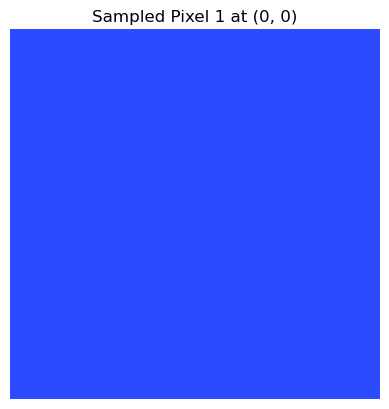

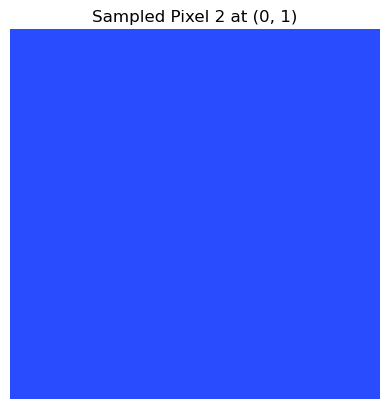

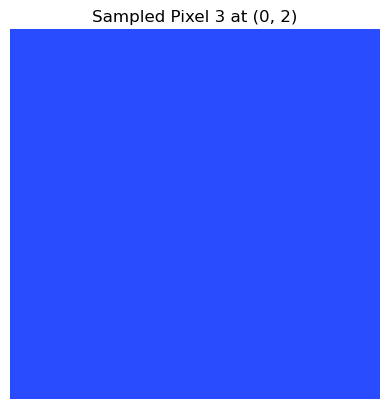

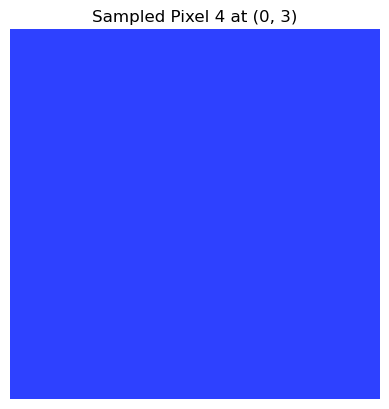

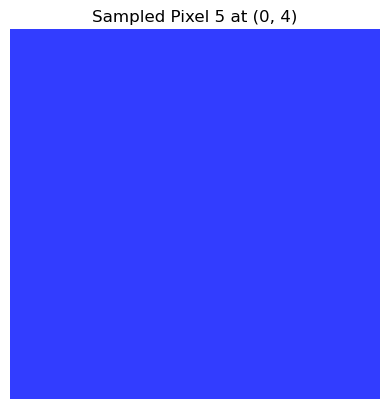

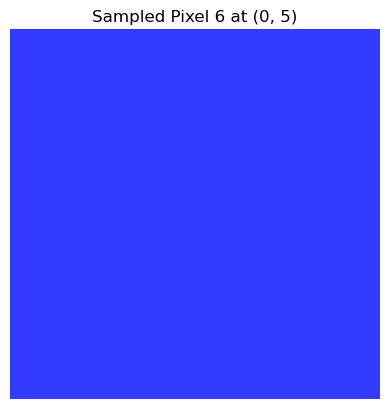

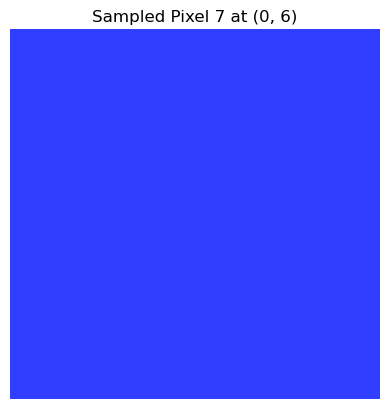

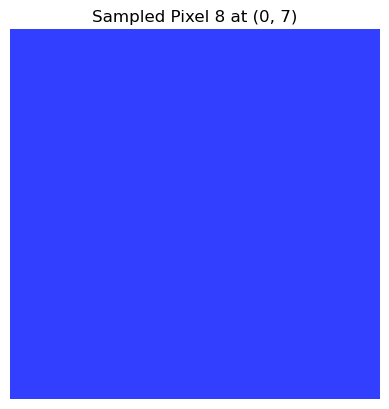

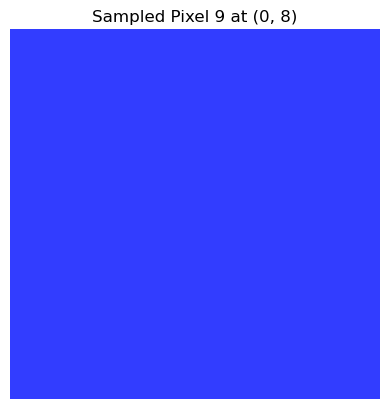

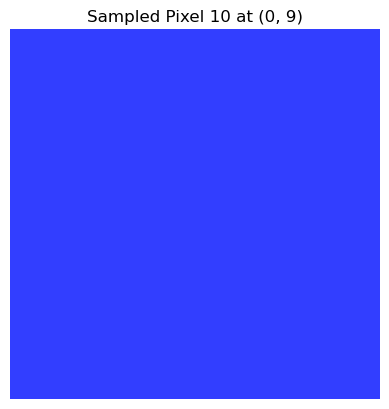

Median quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for blue Pixel 1 at (0, 0): [ 0.7193431  -0.3054508   0.1185355   0.61253136]
Median Quaternion for blue Pixel 2 at (0, 1): [ 0.7222587  -0.30481237  0.11776629  0.60956013]
Median Quaternion for blue Pixel 3 at (0, 2): [ 0.26752776 -0.15459934 -0.75975347  0.57210416]
Median Quaternion for blue Pixel 4 at (0, 3): [ 0.2675557  -0.15492967 -0.7596587   0.5721268 ]
Median Quaternion for blue Pixel 5 at (0, 4): [ 0.72269666 -0.30477482  0.11727791  0.60915303]
Median Quaternion for blue Pixel 6 at (0, 5): [ 0.7172371  -0.30576512  0.13053595  0.61240435]
Median Quaternion for blue Pixel 7 at (0, 6): [ 0.27039996 -0.16590156 -0.7525132   0.57713455]
Median Quaternion for blue Pixel 8 at (0, 7): [ 0.27038926 -0.16615348 -0.7526237   0.5769241 ]
Median Quaternion for blue Pixel 9 at (0, 8): [ 0.7175133  -0.30589578  0.13052318  0.6120179 ]
Median Quaternion for blue Pixel 10 at (0, 9): [ 0.7225263  -0.30472153  0.11754471  

FileNotFoundError: [Errno 2] No such file or directory: '/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Quat_model_best/blue_quaternions.npy'

In [198]:
# get the relevant quaternions
# Contrast the median quaternion values between fz_reduce and not_fz_reduce for the blue pixels
# find x,y indices where labels is 0
x_indices, y_indices = np.where(labels == 0)
# pick 10 random indices from the x_indices and y_indices
import random
import os
random_indices = random.sample(range(len(x_indices)), 10)
# get the x,y coordinates of the random indices
random_x = x_indices[random_indices]
random_y = y_indices[random_indices]
# print the random x,y coordinates
for i in range(len(random_x)):
    print(f"Random pixel {i}: ({random_x[i]}, {random_y[i]})")
# Use first 10 x,y coordinates instead of random sampling
random_x = x_indices[:10]
random_y = y_indices[:10]
# print the first 10 x,y coordinates
for i in range(len(random_x)):
    print(f"First pixel {i}: ({random_x[i]}, {random_y[i]})")
# sample the pixels from the blue grain image at the random x,y coordinates
sampled_pixels = blue_grain[random_y, random_x]
sampled_pixels.shape
# plot the sampled pixels individually
for i in range(len(sampled_pixels)):
    plt.imshow(sampled_pixels[i].reshape(1, -1, 3))  # Reshape to 1x1 pixel
    plt.axis('off')
    plt.title(f"Sampled Pixel {i+1} at ({random_x[i]}, {random_y[i]})")
    plt.show()

# get the relevant quaternions for not_fz_reduced_data
quaternions = not_fz_reduced_data_sampled[:, random_y, random_x, :]
quat_scalar= quaternions[..., -1]  # Assuming the scalar part is the last element in the last dimension
# get the median of the scalar values for each pixel
median_quat_scalar = np.median(quat_scalar, axis=0)

# For each pixel, find the time index where the scalar value is closest to the median
median_quat_indices = np.argmin(np.abs(quat_scalar - median_quat_scalar), axis=0)
# Extract the quaternions corresponding to these indices for each pixel
median_quat = quaternions[median_quat_indices, np.arange(10), :]
print("Median quaternions shape (not fz_reduced):", median_quat.shape)
# Print the median quaternions
for i in range(len(median_quat)):
    print(f"Median Quaternion for blue Pixel {i+1} at ({random_x[i]}, {random_y[i]}): {median_quat[i]}")

##### FZ_REDUCED DATA #####
# get the relevant quaternions for fz_reduced_data
quaternions = fz_reduced_data_sampled[:, random_y, random_x, :]
quat_scalar= quaternions[..., -1]  # Assuming the scalar part is the last element in the last dimension
# get the median of the scalar values for each pixel
median_quat_scalar = np.median(quat_scalar, axis=0)

# For each pixel, find the time index where the scalar value is closest to the median
median_quat_indices = np.argmin(np.abs(quat_scalar - median_quat_scalar), axis=0)
# Extract the quaternions corresponding to these indices for each pixel
median_quat = quaternions[median_quat_indices, np.arange(10), :]
print("Median quaternions shape (fz_reduced):", median_quat.shape)
# Print the median quaternions for blue pixels in the not_fz_reduced_data
for i in range(len(median_quat)):
    print(f"Median Quaternion for blue Pixel {i+1} at ({random_x[i]}, {random_y[i]}): {median_quat[i]}")


# save all quaternions to npy file
quaternions_dir = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Quat_model_best"
np.save(os.path.join(quaternions_dir, "blue_quaternions.npy"),fz_reduced_data_sampled[:, random_y, random_x, :])


In [ ]:
## load npy file
temp_npy = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Test_model_best/Open_718_Test_hr_x_normal_0_x4_HR_transformed_back_0.npy"
npy_data = np.load(temp_npy)
print("Numpy data shape:", npy_data.shape)


Numpy data shape: (301, 390, 4)


In [ ]:
## load npy file
temp_npy = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Quat_model_best/blue_quaternions.npy"
npy_data = np.load(temp_npy)
print("Numpy data shape:", npy_data.shape)


Numpy data shape: (100, 10, 4)


In [ ]:
quaternions.shape

(100, 10, 4)

In [ ]:
######
#BLUE PIXELS
Median quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for blue Pixel 1 at (0, 0): [ 0.7193431  -0.3054508   0.1185355   0.61253136]
Median Quaternion for blue Pixel 2 at (0, 1): [ 0.72214997 -0.30521935  0.11736967  0.6095609 ]
Median Quaternion for blue Pixel 3 at (0, 2): [ 0.26752776 -0.15459934 -0.75975347  0.57210416]
Median Quaternion for blue Pixel 4 at (0, 3): [ 0.2675557  -0.15492967 -0.7596587   0.5721268 ]
Median Quaternion for blue Pixel 5 at (0, 4): [ 0.7227732  -0.30468145  0.11709557  0.60914445]
Median Quaternion for blue Pixel 6 at (0, 5): [ 0.7172371  -0.30576512  0.13053595  0.61240435]
Median Quaternion for blue Pixel 7 at (0, 6): [ 0.2703091  -0.16598648 -0.7525192   0.577145  ]
Median Quaternion for blue Pixel 8 at (0, 7): [ 0.27038926 -0.16615348 -0.7526237   0.5769241 ]
Median Quaternion for blue Pixel 9 at (0, 8): [ 0.7175134  -0.3058958   0.13052318  0.612018  ]
Median Quaternion for blue Pixel 10 at (0, 9): [ 0.7225263  -0.30472153  0.11754471  0.60933053]

Median quaternions shape (fz_reduced): (10, 4)
Median Quaternion for blue Pixel 1 at (0, 0): [ 0.07504171 -0.29972738 -0.13266438  0.94177115]
Median Quaternion for blue Pixel 2 at (0, 1): [ 0.08016635 -0.29843408 -0.13231218  0.9418092 ]
Median Quaternion for blue Pixel 3 at (0, 2): [ 0.0800578  -0.29855603 -0.13238204  0.9417696 ]
Median Quaternion for blue Pixel 4 at (0, 3): [ 0.07942707 -0.29865852 -0.13272333  0.9417425 ]
Median Quaternion for blue Pixel 5 at (0, 4): [ 0.08037322 -0.2983399  -0.13265304  0.9417735 ]
Median Quaternion for blue Pixel 6 at (0, 5): [ 0.07404468 -0.30848798 -0.12386742  0.9402176 ]
Median Quaternion for blue Pixel 7 at (0, 6): [ 0.07424826 -0.30844918 -0.12406623  0.94018763]
Median Quaternion for blue Pixel 8 at (0, 7): [ 0.07475632 -0.3083099  -0.12427451  0.9401658 ]
Median Quaternion for blue Pixel 9 at (0, 8): [ 0.07459649 -0.30859482 -0.12400717  0.94012064]
Median Quaternion for blue Pixel 10 at (0, 9): [ 0.07969592 -0.2986116  -0.13220772  0.9418074 ]

SyntaxError: invalid syntax (1766674561.py, line 3)

In [ ]:
######
# GREEN PIXELSMedian quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for green Pixel 1 at (0, 35): [ 0.8735245  -0.15529749 -0.2895828   0.3591367 ]
Median Quaternion for green Pixel 2 at (0, 36): [0.8230903  0.14433137 0.41218424 0.3630357 ]
Median Quaternion for green Pixel 3 at (0, 38): [ 0.87870115 -0.14718771 -0.2889213   0.3503497 ]
Median Quaternion for green Pixel 4 at (0, 47): [ 0.87538624 -0.16162069 -0.2836091   0.35657272]
Median Quaternion for green Pixel 5 at (1, 11): [ 0.26755545 -0.15491316 -0.75979406  0.5719518 ]
Median Quaternion for green Pixel 6 at (1, 35): [ 0.87613225 -0.16362156 -0.28757912  0.35059625]
Median Quaternion for green Pixel 7 at (1, 37): [ 0.50455785 -0.7342768   0.05033575  0.4513594 ]
Median Quaternion for green Pixel 8 at (1, 51): [ 0.8757872  -0.16105507 -0.28855518  0.35184467]
Median Quaternion for green Pixel 9 at (1, 65): [ 0.8778835 -0.1561515 -0.2719855  0.361886 ]
Median Quaternion for green Pixel 10 at (2, 43): [ 0.87206477 -0.16261166 -0.29352468  0.35623652]
    
Median quaternions shape (fz_reduced): (10, 4)
Median Quaternion for green Pixel 1 at (0, 35): [-0.3591367   0.2895828  -0.15529749  0.8735245 ]
Median Quaternion for green Pixel 2 at (0, 36): [-0.35848257  0.29049897 -0.15469658  0.8735959 ]
Median Quaternion for green Pixel 3 at (0, 38): [-0.35055515  0.28875542 -0.14663595  0.8787662 ]
Median Quaternion for green Pixel 4 at (0, 47): [-0.35547543  0.28148264 -0.16370755  0.876131  ]
Median Quaternion for green Pixel 5 at (1, 11): [ 0.07977104 -0.29855305 -0.13268514  0.94175196]
Median Quaternion for green Pixel 6 at (1, 35): [-0.3498301   0.2890494  -0.16350003  0.87597734]
Median Quaternion for green Pixel 7 at (1, 37): [-0.35512856  0.28265044 -0.16314153  0.87600094]
Median Quaternion for green Pixel 8 at (1, 51): [-0.35081595  0.28936344 -0.15955621  0.8762071 ]
Median Quaternion for green Pixel 9 at (1, 65): [-0.34842786  0.2866108  -0.16228434  0.8775629 ]
Median Quaternion for green Pixel 10 at (2, 43): [-0.35628614  0.29316235 -0.16228208  0.87222767]

SyntaxError: invalid syntax (356433561.py, line 3)

In [ ]:
dir="/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Quat_model_best"
# load npy file
# save green_fz_not_fz_reduced.npy
import os
if not os.path.exists(dir):
    os.makedirs(dir)

green_fz_not_fz_reduced = [
	[ 0.8735245,  -0.15529749, -0.2895828,   0.3591367 ],
	[ 0.8230903,   0.14433137,  0.41218424,  0.3630357 ],
	[ 0.87870115, -0.14718771, -0.2889213,   0.3503497 ],
	[ 0.87538624, -0.16162069, -0.2836091,   0.35657272],
	[ 0.26755545, -0.15491316, -0.75979406,  0.5719518 ],
	[ 0.87613225, -0.16362156, -0.28757912,  0.35059625],
	[ 0.50455785, -0.7342768,   0.05033575,  0.4513594 ],
	[ 0.8757872,  -0.16105507, -0.28855518,  0.35184467],
	[ 0.8778835,  -0.1561515,  -0.2719855,   0.361886 ],
	[ 0.87206477, -0.16261166, -0.29352468,  0.35623652]
]

# add extra column dimension
green_fz_not_fz_reduced = np.array(green_fz_not_fz_reduced)
green_fz_not_fz_reduced = np.expand_dims(green_fz_not_fz_reduced, axis=0)

# save to npy file
np.save(os.path.join(dir, "IPF_green_not_fz_reduced.npy"), green_fz_not_fz_reduced)

green_fz_reduced = [
	[-0.3591367,   0.2895828,  -0.15529749,  0.8735245 ],
	[-0.35848257,  0.29049897, -0.15469658,  0.8735959 ],
	[-0.35055515,  0.28875542, -0.14663595,  0.8787662 ],
	[-0.35547543,  0.28148264, -0.16370755,  0.876131  ],
	[ 0.07977104, -0.29855305, -0.13268514,  0.94175196],
	[-0.3498301,   0.2890494,  -0.16350003,  0.87597734],
	[-0.35512856,  0.28265044, -0.16314153,  0.87600094],
	[-0.35081595,  0.28936344, -0.15955621,  0.8762071 ],
	[-0.34842786,  0.2866108,  -0.16228434,  0.8775629 ],
	[-0.35628614,  0.29316235, -0.16228208,  0.87222767]
]

# add extra column dimension
green_fz_reduced = np.array(green_fz_reduced)
green_fz_reduced = np.expand_dims(green_fz_reduced, axis=0)

# save to npy file
np.save(os.path.join(dir, "IPF_green_fz_reduced.npy"), green_fz_reduced)


In [ ]:
Median quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for blue Pixel 1 at (0, 0): [ 0.7193431  -0.3054508   0.1185355   0.61253136]
Median Quaternion for blue Pixel 2 at (0, 1): [ 0.72214997 -0.30521935  0.11736967  0.6095609 ]
Median Quaternion for blue Pixel 3 at (0, 2): [ 0.26752776 -0.15459934 -0.75975347  0.57210416]
Median Quaternion for blue Pixel 4 at (0, 3): [ 0.2675557  -0.15492967 -0.7596587   0.5721268 ]
Median Quaternion for blue Pixel 5 at (0, 4): [ 0.7227732  -0.30468145  0.11709557  0.60914445]
Median Quaternion for blue Pixel 6 at (0, 5): [ 0.7172371  -0.30576512  0.13053595  0.61240435]
Median Quaternion for blue Pixel 7 at (0, 6): [ 0.2703091  -0.16598648 -0.7525192   0.577145  ]
Median Quaternion for blue Pixel 8 at (0, 7): [ 0.27038926 -0.16615348 -0.7526237   0.5769241 ]
Median Quaternion for blue Pixel 9 at (0, 8): [ 0.7175134  -0.3058958   0.13052318  0.612018  ]
Median Quaternion for blue Pixel 10 at (0, 9): [ 0.7225263  -0.30472153  0.11754471  0.60933053]

Median quaternions shape (fz_reduced): (10, 4)
Median Quaternion for blue Pixel 1 at (0, 0): [ 0.07504171 -0.29972738 -0.13266438  0.94177115]
Median Quaternion for blue Pixel 2 at (0, 1): [ 0.08016635 -0.29843408 -0.13231218  0.9418092 ]
Median Quaternion for blue Pixel 3 at (0, 2): [ 0.0800578  -0.29855603 -0.13238204  0.9417696 ]
Median Quaternion for blue Pixel 4 at (0, 3): [ 0.07942707 -0.29865852 -0.13272333  0.9417425 ]
Median Quaternion for blue Pixel 5 at (0, 4): [ 0.08037322 -0.2983399  -0.13265304  0.9417735 ]
Median Quaternion for blue Pixel 6 at (0, 5): [ 0.07404468 -0.30848798 -0.12386742  0.9402176 ]
Median Quaternion for blue Pixel 7 at (0, 6): [ 0.07424826 -0.30844918 -0.12406623  0.94018763]
Median Quaternion for blue Pixel 8 at (0, 7): [ 0.07475632 -0.3083099  -0.12427451  0.9401658 ]
Median Quaternion for blue Pixel 9 at (0, 8): [ 0.07459649 -0.30859482 -0.12400717  0.94012064]
Median Quaternion for blue Pixel 10 at (0, 9): [ 0.07969592 -0.2986116  -0.13220772  0.9418074 ]

In [ ]:
dir="/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Quat_model_best"

# load npy file
# save green_fz_not_fz_reduced.npy
import os
if not os.path.exists(dir):
    os.makedirs(dir)

blue_fz_not_fz_reduced = [
    [0.7193431, -0.3054508, 0.1185355, 0.61253136],
    [0.72214997, -0.30521935, 0.11736967, 0.6095609],
    [0.26752776, -0.15459934, -0.75975347, 0.57210416],
    [0.2675557, -0.15492967, -0.7596587, 0.5721268],
    [0.7227732, -0.30468145, 0.11709557, 0.60914445],
    [0.7172371, -0.30576512, 0.13053595, 0.61240435],
    [0.2703091, -0.16598648, -0.7525192, 0.577145],
    [0.27038926, -0.16615348, -0.7526237, 0.5769241],
    [0.7175134, -0.3058958, 0.13052318, 0.612018],
    [0.7225263, -0.30472153, 0.11754471, 0.60933053]
]

# add extra column dimension
blue_fz_not_fz_reduced = np.array(blue_fz_not_fz_reduced)
blue_fz_not_fz_reduced = np.expand_dims(blue_fz_not_fz_reduced, axis=0)

# save to npy file
np.save(os.path.join(dir, "IPF_blue_not_fz_reduced.npy"), blue_fz_not_fz_reduced)

blue_fz_reduced = [ 
    [0.07504171, -0.29972738, -0.13266438, 0.94177115],
    [0.08016635, -0.29843408, -0.13231218, 0.9418092],
    [0.0800578, -0.29855603, -0.13238204, 0.9417696],
    [0.07942707, -0.29865852, -0.13272333, 0.9417425],
    [0.08037322, -0.2983399, -0.13265304, 0.9417735],
    [0.07404468, -0.30848798, -0.12386742, 0.9402176],
    [0.07424826, -0.30844918, -0.12406623, 0.94018763],
    [0.07475632, -0.3083099, -0.12427451, 0.9401658],
    [0.07459649, -0.30859482, -0.12400717, 0.94012064],
    [0.07969592, -0.2986116, -0.13220772, 0.9418074]
]
# add extra column dimension
blue_fz_reduced = np.array(blue_fz_reduced)
blue_fz_reduced = np.expand_dims(blue_fz_reduced, axis=0)

# save to npy file
np.save(os.path.join(dir, "IPF_blue_fz_reduced.npy"), blue_fz_reduced)

## Read the actual quaternion values.

In [ ]:
import numpy as np
npy_dir= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Test_model_best/Open_718_Test_hr_x_normal_0_x4_SR_transformed.npy"

# load npy file
srfz_data = np.load(npy_dir)
print("Shape of loaded SR data:", srfz_data.shape)
# Check the shape of the loaded data

Shape of loaded SR data: (304, 390, 4)


In [ ]:
sampled_data

array([[[ 0.0755059 , -0.29974785, -0.13288018,  0.94169694],
        [ 0.08028109, -0.29862517, -0.13227378,  0.941744  ],
        [ 0.07543083, -0.2997549 , -0.13266356,  0.9417314 ],
        ...,
        [-0.35568887,  0.2788942 , -0.1748921 ,  0.87470937],
        [-0.35944444,  0.2766345 , -0.16913667,  0.87502354],
        [-0.35738704,  0.27491844, -0.16758847,  0.87670326]],

       [[ 0.07567979, -0.29989588, -0.13268383,  0.9416635 ],
        [ 0.08041821, -0.29861295, -0.13237193,  0.94172245],
        [ 0.07550622, -0.29974416, -0.1326892 ,  0.941725  ],
        ...,
        [-0.3556607 ,  0.27835292, -0.17479792,  0.874912  ],
        [-0.35958356,  0.27585912, -0.16919878,  0.875199  ],
        [-0.35752317,  0.27383566, -0.16792375,  0.87692255]],

       [[ 0.07537435, -0.29988125, -0.13212307,  0.94177175],
        [ 0.08012243, -0.2983203 , -0.13260004,  0.94180846],
        [ 0.07508139, -0.29956794, -0.13238752,  0.94185776],
        ...,
        [-0.35883424,  0.28

In [ ]:
# sample the big blue grain image at the random x,y coordinates
sampled_srfz = srfz_data[90:220, 140:220, :]

In [ ]:
## Get random blue pixels 
# Contrast the median quaternion values between fz_reduce and not_fz_reduce for the green pixels
# find x,y indices where labels is 1
x_indices, y_indices = np.where(labels == 0)
# pick 10 random indices from the x_indices and y_indices

import random
random_indices = random.sample(range(len(x_indices)), 10)
# get the x,y coordinates of the random indices
random_x = x_indices[random_indices]
random_y = y_indices[random_indices]

# print the random x,y coordinates
for i in range(len(random_x)):
    print(f"Random pixel {i}: ({random_x[i]}, {random_y[i]})")
# Use first 10 x,y coordinates instead of random sampling
random_x = x_indices[:10]
random_y = y_indices[:10]
# print the first 10 x,y coordinates
for i in range(len(random_x)):
    print(f"First 10 pixel {i}: ({random_x[i]}, {random_y[i]})")

Random pixel 0: (36, 48)
Random pixel 1: (71, 37)
Random pixel 2: (27, 63)
Random pixel 3: (110, 68)
Random pixel 4: (53, 13)
Random pixel 5: (102, 69)
Random pixel 6: (14, 51)
Random pixel 7: (70, 50)
Random pixel 8: (33, 13)
Random pixel 9: (89, 66)
First 10 pixel 0: (0, 0)
First 10 pixel 1: (0, 1)
First 10 pixel 2: (0, 2)
First 10 pixel 3: (0, 3)
First 10 pixel 4: (0, 4)
First 10 pixel 5: (0, 5)
First 10 pixel 6: (0, 6)
First 10 pixel 7: (0, 7)
First 10 pixel 8: (0, 8)
First 10 pixel 9: (0, 9)


In [ ]:
## Now get the blue and green pixels from the sampled_srfz data using the same random x,y coordinates
import matplotlib.pyplot as plt
# Assuming you have the random_x and random_y coordinates from the previous steps
sampled_srfz_blue = sampled_srfz[random_y, random_x, :]

In [ ]:
# randomx, random_y are the coordinates of the blue pixels in the sampled_srfz data
# print not plot
for i in range(len(sampled_srfz_blue)):
    print(f"Sampled SR pixel {i}: ({random_x[i]}, {random_y[i]}) - Value: {sampled_srfz_blue[i]}")

Sampled SR pixel 0: (0, 0) - Value: [ 0.07519197 -0.29955003 -0.1322388   0.9418752 ]
Sampled SR pixel 1: (0, 1) - Value: [ 0.08001825 -0.29819864 -0.13242827  0.94187975]
Sampled SR pixel 2: (0, 2) - Value: [ 0.08011803 -0.29854295 -0.13250461  0.9417515 ]
Sampled SR pixel 3: (0, 3) - Value: [ 0.07942708 -0.29865855 -0.13272335  0.94174254]
Sampled SR pixel 4: (0, 4) - Value: [ 0.08009727 -0.29812315 -0.13287303  0.9418343 ]
Sampled SR pixel 5: (0, 5) - Value: [ 0.074155   -0.30829856 -0.12376115  0.9402852 ]
Sampled SR pixel 6: (0, 6) - Value: [ 0.07429372 -0.30876523 -0.12384249  0.9401104 ]
Sampled SR pixel 7: (0, 7) - Value: [ 0.07352056 -0.30877015 -0.1243194   0.94010663]
Sampled SR pixel 8: (0, 8) - Value: [ 0.07423218 -0.30825853 -0.12415279  0.9402406 ]
Sampled SR pixel 9: (0, 9) - Value: [ 0.08006574 -0.29804125 -0.13226533  0.9419484 ]
